<a href="https://colab.research.google.com/github/benniella/Ml-learning/blob/main/Hotel_Booking_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*force_all_finite.*")


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
df = pd.read_csv('Hotel.csv')
df.head()

,Time,Value
0,2024-01-31,-0.416281
1,2024-02-29,5.558282
2,2024-03-31,6.778557
3,2024-04-30,5.948707
4,2024-05-31,4.844693


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    200 non-null    object 
 1   Value   200 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.2+ KB


In [ ]:
df.isnull().sum()

,0
Time,0
Value,0


In [ ]:
model = SARIMAX(df['Value'], order=(2, 1, 1), seasonal_order=(1, 0, 1,12))
results = model.fit()
print(results)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
model = ARIMA(df['Value'], order=(1, 1, 1))
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(df.index[-1], periods=forecast_steps + 1, freq='M')[1:]

<ipython-input-29-3ea4ed61528a>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(df.index[-1], periods=forecast_steps + 1, freq='M')[1:]


In [ ]:
forecast = results.get_forecast(steps=12)
forecast_index = forecast.predicted_mean.index
print(forecast_index)

DatetimeIndex(['2040-09-30', '2040-10-31', '2040-11-30', '2040-12-31',
               '2041-01-31', '2041-02-28', '2041-03-31', '2041-04-30',
               '2041-05-31', '2041-06-30', '2041-07-31', '2041-08-31'],
              dtype='datetime64[ns]', freq='ME')


In [ ]:
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

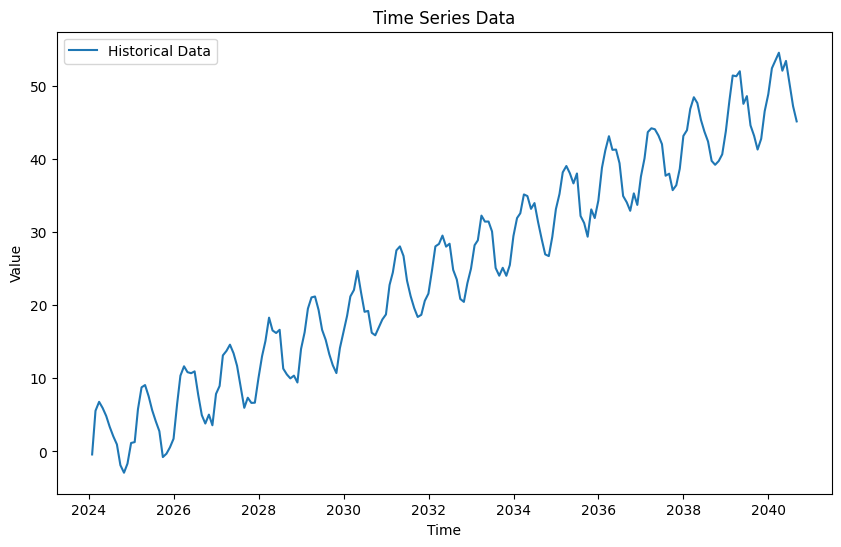

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Value'], label='Historical Data')
plt.title('Time Series Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

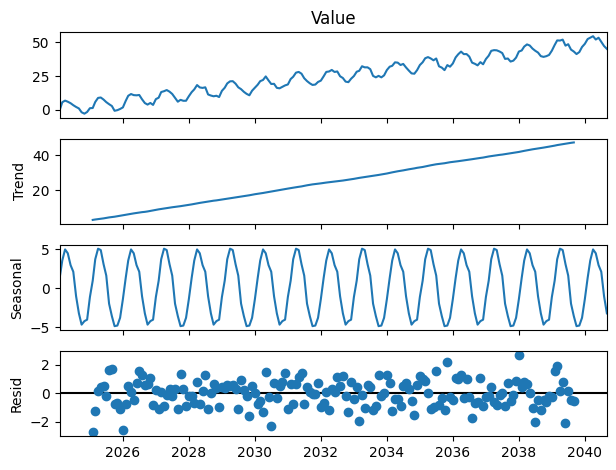

In [ ]:
decomposition = seasonal_decompose(df['Value'], model='additive', period=24)

# Plot decomposition
decomposition.plot()
plt.show()

In [ ]:
model = auto_arima(
    df['Value'],
    seasonal=True,
    m=12,                # Seasonal period (365 for yearly seasonality)
    max_p=2,              # Maximum AR terms
    max_d=1,              # Maximum differencing terms
    max_q=2,              # Maximum MA terms
    max_P=1,              # Maximum seasonal AR terms
    max_D=1,              # Maximum seasonal differencing terms
    max_Q=1,              # Maximum seasonal MA terms
    stepwise=False,       # Disable stepwise search to reduce time
    trace=True,           # Show progress
    error_action="ignore" # Ignore errors and continue
)

print(model.summary())

 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=903.508, Time=0.04 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=842.214, Time=0.21 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=787.587, Time=0.16 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=884.370, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=843.265, Time=0.19 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=5.03 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=864.033, Time=0.10 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=830.011, Time=0.27 sec
 ARIMA(0,1,2)(1,0,0)[12] intercept   : AIC=inf, Time=0.83 sec
 ARIMA(0,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.49 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=872.078, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=842.409, Time=0.21 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=758.839, Time=0.18 sec
 ARIMA(1,1,0)(1,0,1)[12] inter

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  200
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -325.629
Date:                            Fri, 10 Jan 2025   AIC                            663.259
Time:                                    16:26:58   BIC                            683.018
Sample:                                01-31-2024   HQIC                           671.256
                                     - 08-31-2040                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1390      0.075      1.862      0.063      -0.007       0.285
ar.L2          0.0436      0.086   

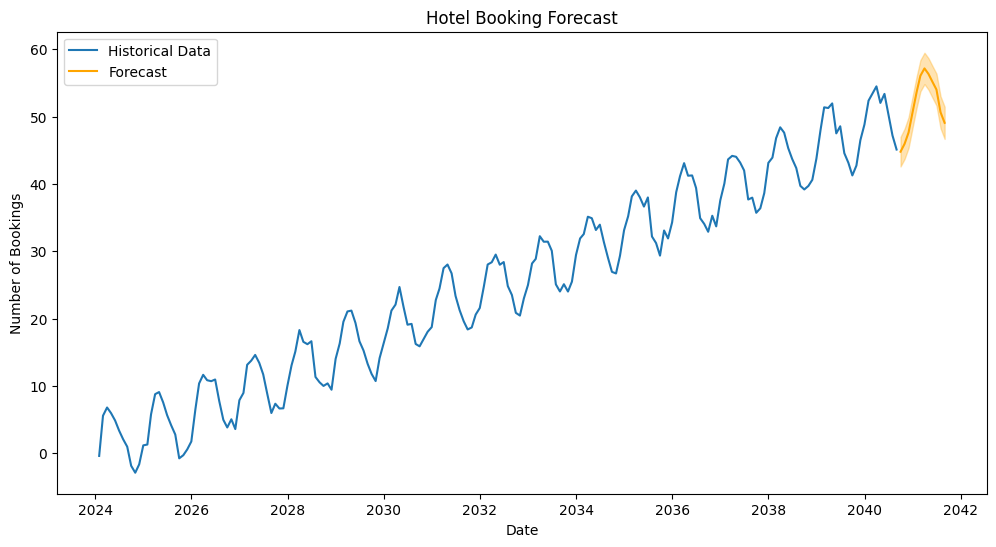

In [ ]:
df = pd.read_csv('Hotel.csv', parse_dates=['Time'], index_col='Time')


model = SARIMAX(df['Value'], order=(2, 1, 1), seasonal_order=(1, 0, 1, 12))
results = model.fit()


print(results.summary())

# Generate forecast for the next 30 days
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_index = forecast.predicted_mean.index

# Get confidence intervals
conf_int = forecast.conf_int()

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Value'], label='Historical Data')
plt.plot(forecast_index, forecast.predicted_mean, label='Forecast', color='orange')
plt.fill_between(forecast_index, conf_int['lower Value'], conf_int['upper Value'], color='orange', alpha=0.3)
plt.title('Hotel Booking Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.legend()
plt.show()
